# Neural Network Hyperparameter Tuning — Audio Features

This notebook performs systematic hyperparameter optimization for the audio-feature neural network.
We reuse the train/dev/test split logic to avoid song-id leakage, then sweep across network depths, widths,
regularization strengths, activation functions, dropout usage, and learning-rate schedules. Results include per-epoch
histories and aggregate metrics so we can spot the best configurations.

In [1]:
from pathlib import Path
import logging
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, roc_auc_score
from tqdm.auto import tqdm

from ml.data import (
    AUDIO_FEATURES,
    RANK_COLUMN,
    create_classification_splits,
    load_classification_dataframe,
)
from ml.models import build_neural_network
from ml.train import train_model, plot_training_history


/Users/hallaei/miniconda3/envs/aml_cwl/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')

In [3]:
DATA_PATH = Path('data/datasets/Spotify_Dataset_V3.csv')
TOP_K = 10
FEATURE_SET_NAME = 'Audio Features'
HOLDOUT_FRACTION = 0.4
DEV_SHARE = 0.5
RANDOM_STATE = 51
MAX_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 3
EARLY_STOPPING_MIN_DELTA = 1e-3

feature_cols = AUDIO_FEATURES


In [4]:
classification_df, target_col = load_classification_dataframe(
    DATA_PATH, feature_cols, RANK_COLUMN, TOP_K, FEATURE_SET_NAME
)
train_df, dev_df, test_df = create_classification_splits(
    classification_df,
    target_col,
    HOLDOUT_FRACTION,
    DEV_SHARE,
    RANDOM_STATE,
)
print(
    f'Train={len(train_df)} Dev={len(dev_df)} Test={len(test_df)} | '
    f'Positive rates -> Train {train_df[target_col].mean():.2%}, '
    f'Dev {dev_df[target_col].mean():.2%}, Test {test_df[target_col].mean():.2%}'
)


2025-11-19 23:37:16,258 [INFO] Loading dataset from data/datasets/Spotify_Dataset_V3.csv
2025-11-19 23:37:17,681 [INFO] Prepared dataframe with 651936 songs (positive rate 4.82%).
2025-11-19 23:37:17,700 [INFO] Creating splits with holdout_fraction=0.40 and dev_share=0.50


Engineering Audio Features...


2025-11-19 23:37:17,874 [INFO] Split sizes -> train=395328, dev=126410, test=130198
2025-11-19 23:37:17,885 [INFO] Train split positive rate: 4.73%
2025-11-19 23:37:17,886 [INFO] Dev split positive rate: 4.81%
2025-11-19 23:37:17,888 [INFO] Test split positive rate: 5.08%


Train=395328 Dev=126410 Test=130198 | Positive rates -> Train 4.73%, Dev 4.81%, Test 5.08%


In [5]:
dataset_splits = {
    'Train': (train_df[feature_cols], train_df[target_col]),
    'Dev': (dev_df[feature_cols], dev_df[target_col]),
    'Test': (test_df[feature_cols], test_df[target_col]),
}
classes = sorted(train_df[target_col].unique())

## Hyperparameter grid

In [6]:
hidden_layer_options = [
    (32,),
    (64,),
    (64, 32),
    (128, 64),
]
alpha_options = [1e-4, 1e-3, 1e-2]
activation_options = ['relu', 'tanh']
learning_rate_options = ['constant', 'adaptive']
learning_rate_init_options = [0.001, 0.01]
momentum_options = [0.0, 0.9]
dropout_options = [0.0, 0.2]

search_space = []
for hidden_layers, alpha, activation, lr, lr_init, momentum, dropout_rate in product(
    hidden_layer_options,
    alpha_options,
    activation_options,
    learning_rate_options,
    learning_rate_init_options,
    momentum_options,
    dropout_options,
):
    search_space.append({
        'hidden_layers': hidden_layers,
        'alpha': alpha,
        'activation': activation,
        'learning_rate': lr,
        'learning_rate_init': lr_init,
        'momentum': momentum,
        'dropout_rate': dropout_rate,
    })

len(search_space)


384

## Training helper

In [7]:
def build_dropout_model(random_state, hidden_layers, alpha, activation, learning_rate, learning_rate_init, momentum, dropout_rate):
    base_pipeline = build_neural_network(
        random_state=random_state,
        hidden_layer_sizes=hidden_layers,
        alpha=alpha,
    )
    classifier = base_pipeline.named_steps['classifier']
    classifier.set_params(
        activation=activation,
        learning_rate=learning_rate,
        learning_rate_init=learning_rate_init,
        momentum=momentum,
    )
    if dropout_rate > 0:
        classifier.n_iter_no_change = 15
        classifier.beta_1 = 0.9
    return base_pipeline


def evaluate_run(model, history_df, dev_data):
    X_dev, y_dev = dev_data
    y_pred = model.predict(X_dev)
    dev_acc = accuracy_score(y_dev, y_pred)
    scores = model.predict_proba(X_dev)[:, 1]
    dev_auc = roc_auc_score(y_dev, scores)
    best_row = history_df.loc[history_df['val_loss'].idxmin()]
    return dev_acc, dev_auc, best_row['val_loss']


## Run sweep

In [8]:
results = []
train_histories = {}
progress = tqdm(search_space, desc='Hyperparameter configs')
for config in progress:
    config_name = (
        f"layers={config['hidden_layers']} alpha={config['alpha']} act={config['activation']} "
        f"lr={config['learning_rate']} lr_init={config['learning_rate_init']} "
        f"momentum={config['momentum']} dropout={config['dropout_rate']}"
    )
    progress.set_postfix_str(config_name)
    model = build_neural_network(
        RANDOM_STATE,
        hidden_layer_sizes=config['hidden_layers'],
        alpha=config['alpha'],
    )
    classifier = model.named_steps['classifier']
    classifier.set_params(
        activation=config['activation'],
        learning_rate=config['learning_rate'],
        learning_rate_init=config['learning_rate_init'],
        momentum=config['momentum'],
    )
    model, history_df = train_model(
        model,
        dataset_splits['Train'],
        dataset_splits['Dev'],
        epochs=MAX_EPOCHS,
        classes=classes,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
    )
    dev_acc, dev_auc, best_dev_loss = evaluate_run(model, history_df, dataset_splits['Dev'])
    result = {
        **config,
        'best_val_loss': best_dev_loss,
        'dev_accuracy': dev_acc,
        'dev_auc': dev_auc,
        'epochs_run': len(history_df),
    }
    results.append(result)
    train_histories[config_name] = history_df

results_df = pd.DataFrame(results).sort_values('best_val_loss').reset_index(drop=True)
results_df.head()


Hyperparameter configs:   0%|          | 0/384 [00:00<?, ?it/s, layers=(32,) alpha=0.0001 act=relu lr=constant lr_init=0.001 momentum=0.0 dropout=0.0]2025-11-19 23:37:19,451 [INFO] Epoch 1/15 - loss: 0.2395 - val_loss: 0.2459 - accuracy: 0.9527 - val_accuracy: 0.9519 - auc: 0.5018 - val_auc: 0.4716
2025-11-19 23:37:21,339 [INFO] Epoch 2/15 - loss: 0.2069 - val_loss: 0.2148 - accuracy: 0.9527 - val_accuracy: 0.9519 - auc: 0.5114 - val_auc: 0.4709
2025-11-19 23:37:23,275 [INFO] Epoch 3/15 - loss: 0.1985 - val_loss: 0.2069 - accuracy: 0.9527 - val_accuracy: 0.9519 - auc: 0.5193 - val_auc: 0.4730
2025-11-19 23:37:25,735 [INFO] Epoch 4/15 - loss: 0.1954 - val_loss: 0.2040 - accuracy: 0.9527 - val_accuracy: 0.9519 - auc: 0.5254 - val_auc: 0.4737
2025-11-19 23:37:27,893 [INFO] Epoch 5/15 - loss: 0.1939 - val_loss: 0.2025 - accuracy: 0.9527 - val_accuracy: 0.9519 - auc: 0.5308 - val_auc: 0.4740
2025-11-19 23:37:30,782 [INFO] Epoch 6/15 - loss: 0.1930 - val_loss: 0.2016 - accuracy: 0.9527 - val

,hidden_layers,alpha,activation,learning_rate,learning_rate_init,momentum,dropout_rate,best_val_loss,dev_accuracy,dev_auc,epochs_run
0,"(32,)",0.0001,tanh,adaptive,0.01,0.9,0.2,0.191217,0.951863,0.571685,4
1,"(32,)",0.0001,tanh,adaptive,0.01,0.9,0.0,0.191217,0.951863,0.571685,4
2,"(32,)",0.0001,tanh,constant,0.01,0.9,0.2,0.191217,0.951863,0.571685,4
3,"(32,)",0.0001,tanh,constant,0.01,0.9,0.0,0.191217,0.951863,0.571685,4
4,"(32,)",0.0010,tanh,constant,0.01,0.9,0.2,0.191218,0.951863,0.571894,4


In [15]:
# save results_df to csv
results_df.to_csv('nn_hyperparameter_search_results.csv', index=False)

## Results summary

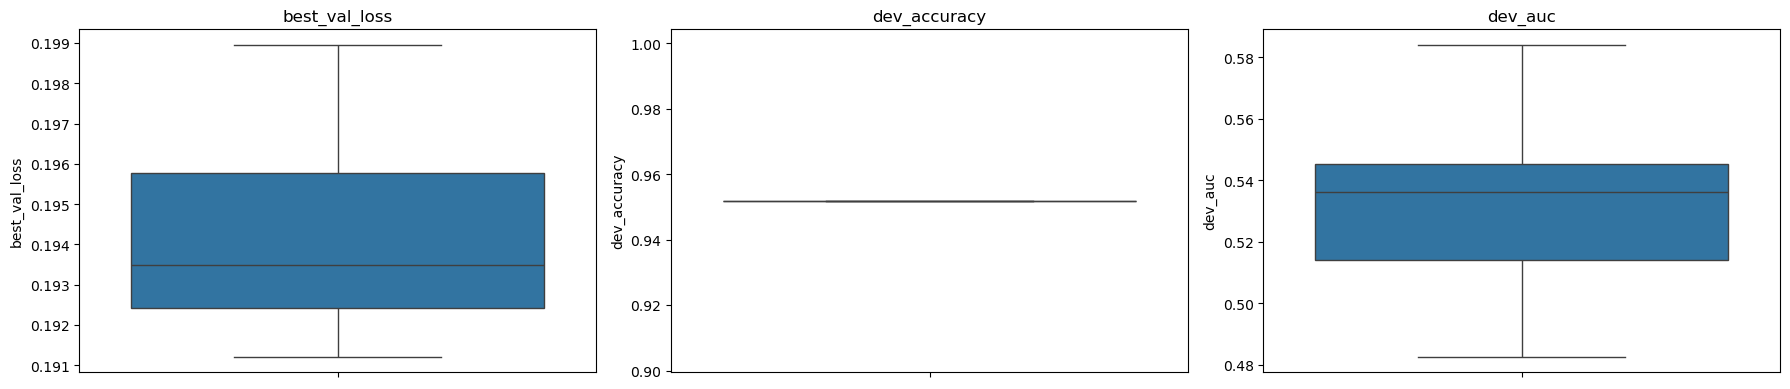

,hidden_layers,alpha,activation,learning_rate,learning_rate_init,momentum,dropout_rate,best_val_loss,dev_accuracy,dev_auc
0,"(32,)",0.0001,tanh,adaptive,0.01,0.9,0.2,0.191217,0.951863,0.571685
1,"(32,)",0.0001,tanh,adaptive,0.01,0.9,0.0,0.191217,0.951863,0.571685
2,"(32,)",0.0001,tanh,constant,0.01,0.9,0.2,0.191217,0.951863,0.571685
3,"(32,)",0.0001,tanh,constant,0.01,0.9,0.0,0.191217,0.951863,0.571685
4,"(32,)",0.0010,tanh,constant,0.01,0.9,0.2,0.191218,0.951863,0.571894
5,"(32,)",0.0010,tanh,constant,0.01,0.9,0.0,0.191218,0.951863,0.571894
6,"(32,)",0.0010,tanh,adaptive,0.01,0.9,0.2,0.191218,0.951863,0.571894
7,"(32,)",0.0010,tanh,adaptive,0.01,0.9,0.0,0.191218,0.951863,0.571894
8,"(32,)",0.0100,tanh,constant,0.01,0.9,0.0,0.191229,0.951863,0.571522
9,"(32,)",0.0100,tanh,constant,0.01,0.9,0.2,0.191229,0.951863,0.571522


In [10]:
metrics = ['best_val_loss', 'dev_accuracy', 'dev_auc']
fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 4))
for ax, metric in zip(axes, metrics):
    sns.boxplot(data=results_df, y=metric, ax=ax)
    ax.set_title(metric)
plt.tight_layout()
plt.show()

results_df[['hidden_layers', 'alpha', 'activation', 'learning_rate', 'learning_rate_init', 'momentum', 'dropout_rate', 'best_val_loss', 'dev_accuracy', 'dev_auc']].head(10)


## Metric trends

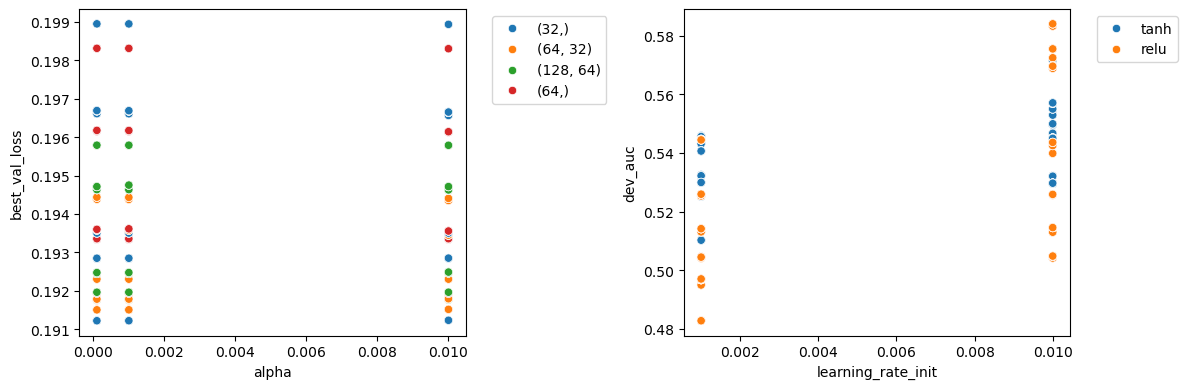

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=results_df, x='alpha', y='best_val_loss', hue='hidden_layers', ax=axes[0])
sns.scatterplot(data=results_df, x='learning_rate_init', y='dev_auc', hue='activation', ax=axes[1])
for ax in axes:
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Inspect top configurations

In [12]:
# # Order results by lowest validation loss
filtered_results = results_df.sort_values('best_val_loss')
# filtered_results.head(3)

# # We need to find config with smallest val loss but where accuracy changes accross epochs as well
# num_iterations = 0
# for idx, row in filtered_results.iterrows():
#     if num_iterations >= 100:
#         break
#     key = (
#         f"layers={row['hidden_layers']} alpha={row['alpha']} act={row['activation']} "
#         f"lr={row['learning_rate']} lr_init={row['learning_rate_init']} momentum={row['momentum']} "
#         f"dropout={row['dropout_rate']}"
#     )
#     history_df = train_histories[key]
#     # Check if the final auc_value for each run is bigger than the initial auc_value
#     if history_df['val_auc'].iloc[-1] > history_df['val_auc'].iloc[0]:
#         plot_training_history(history_df, title=key)
#         num_iterations += 1

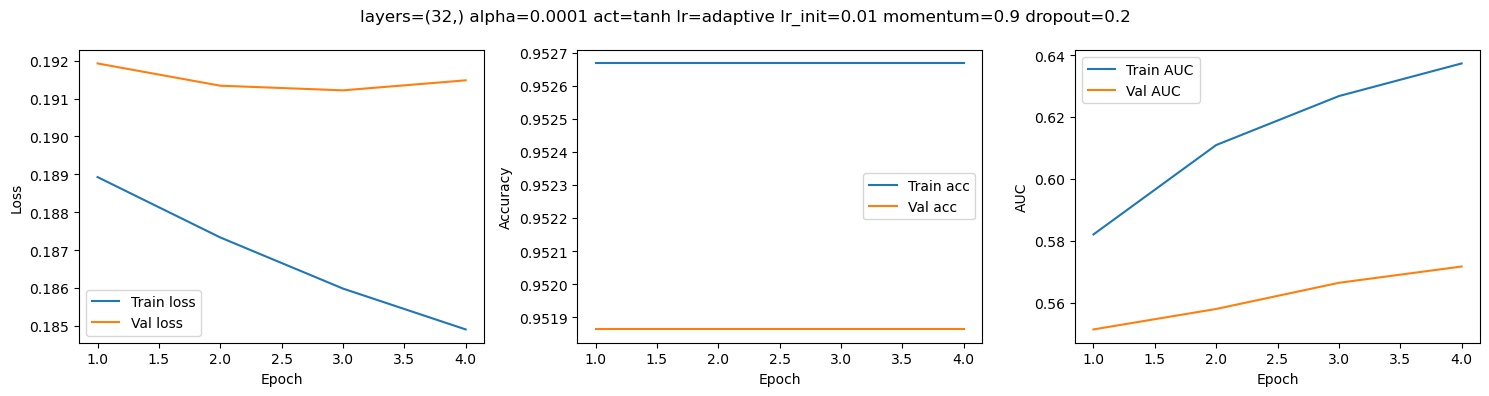

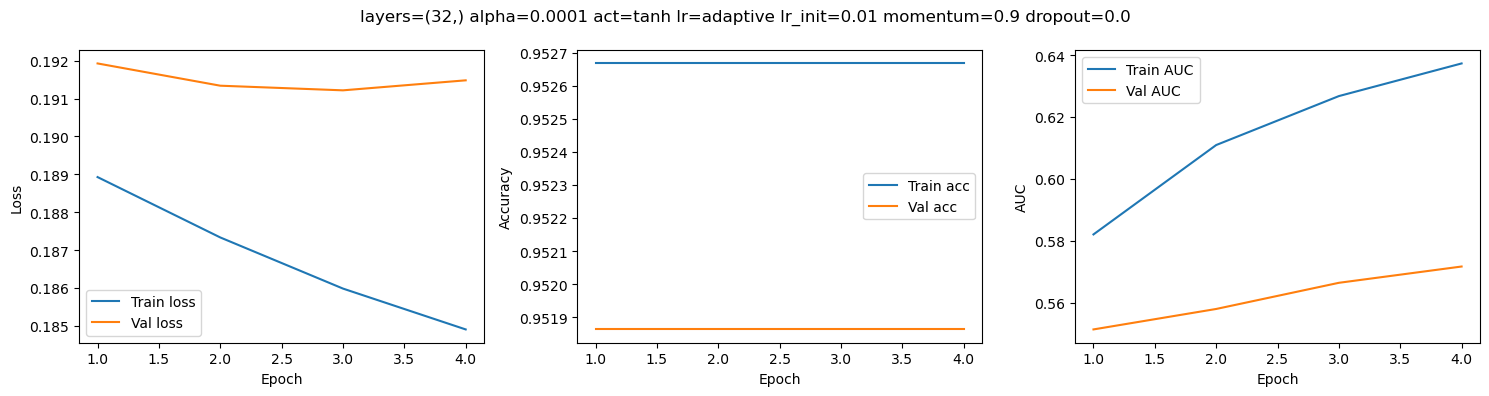

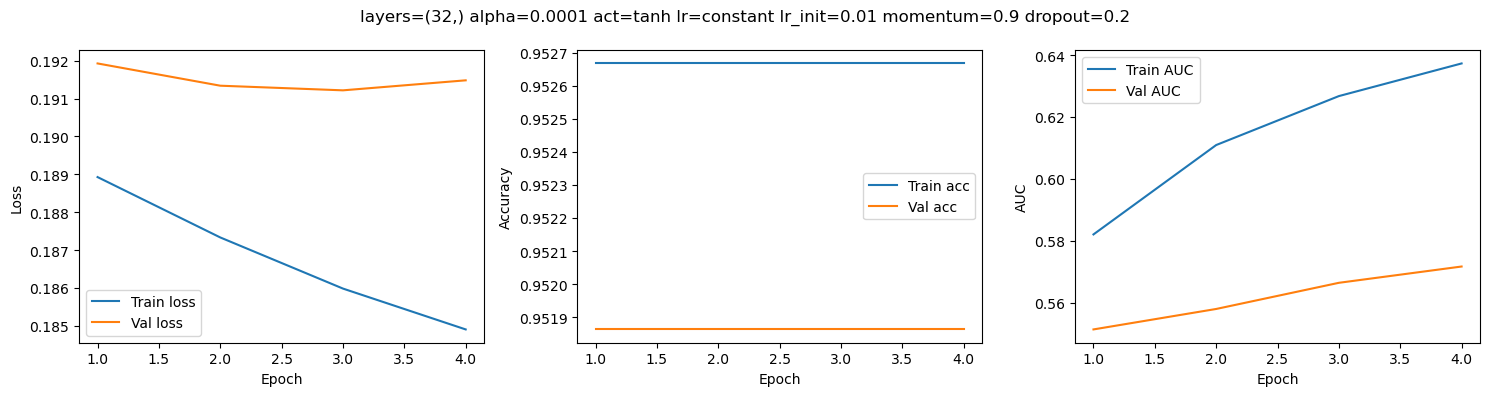

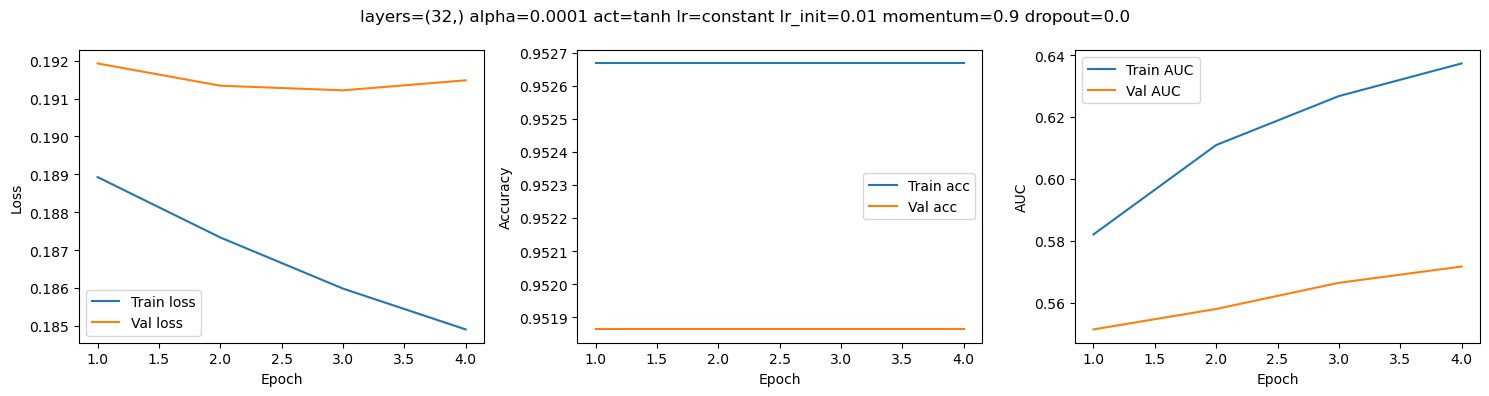

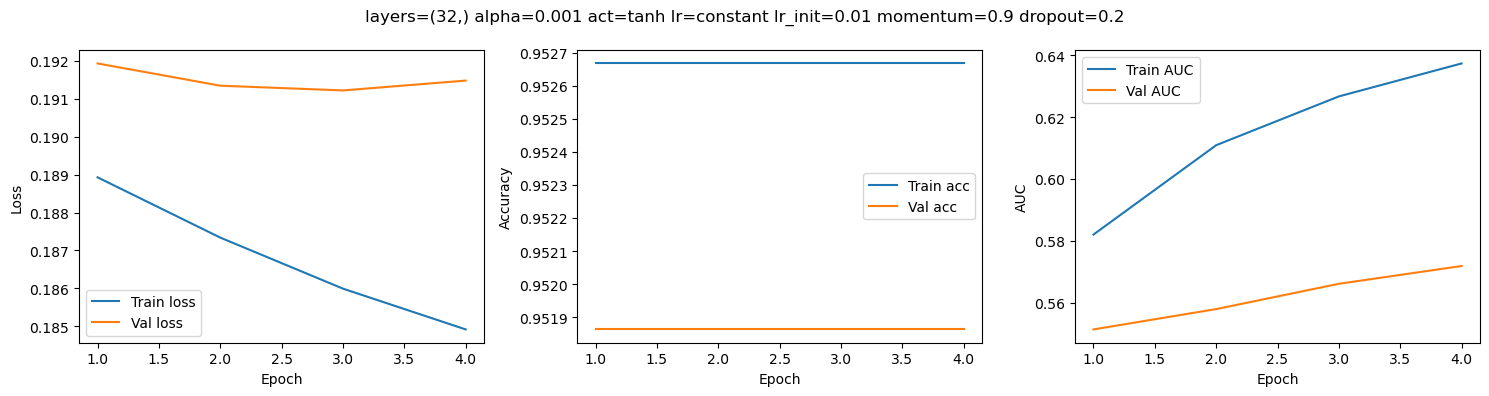

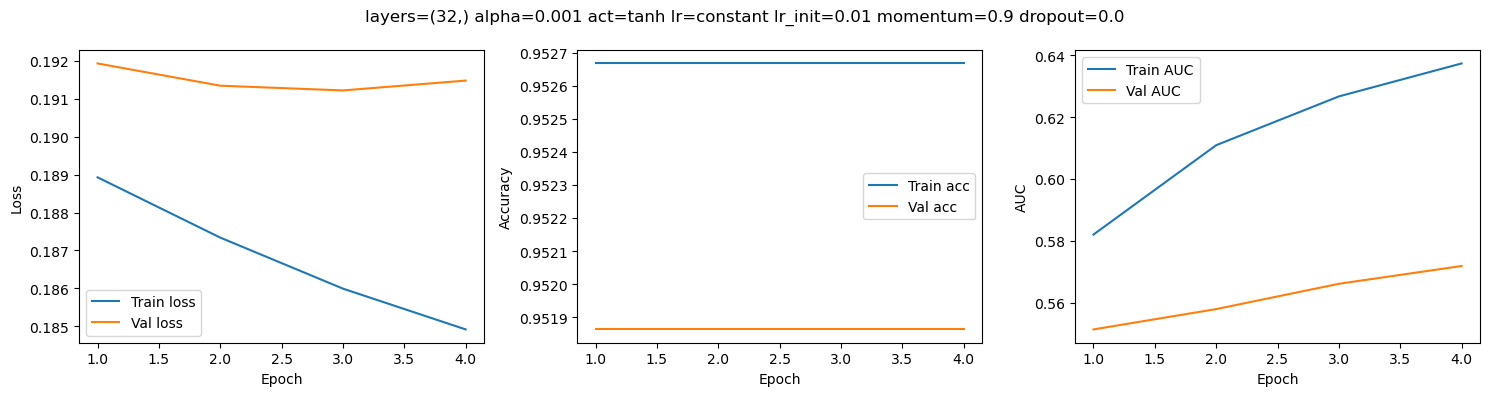

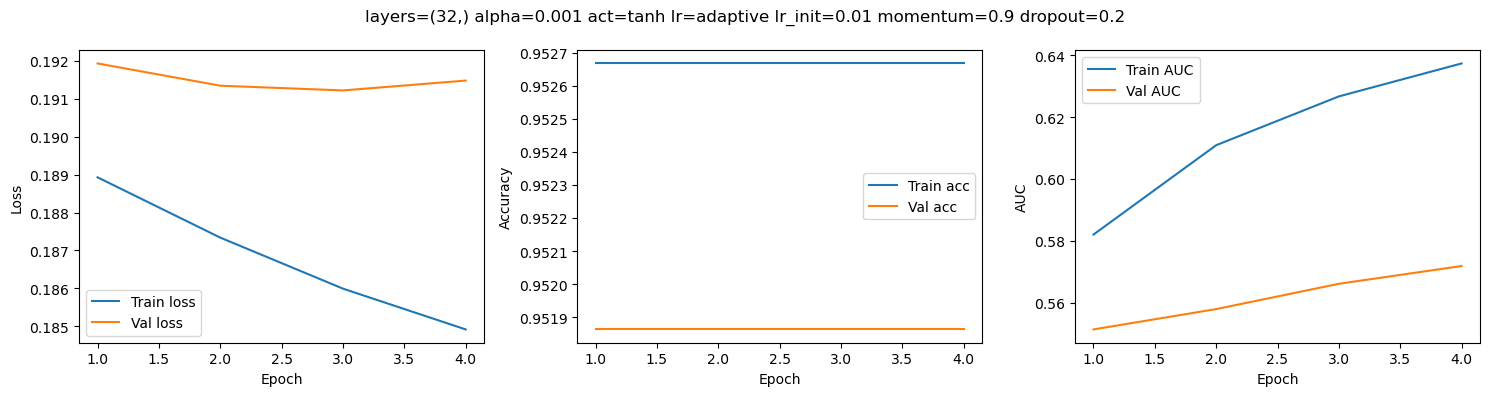

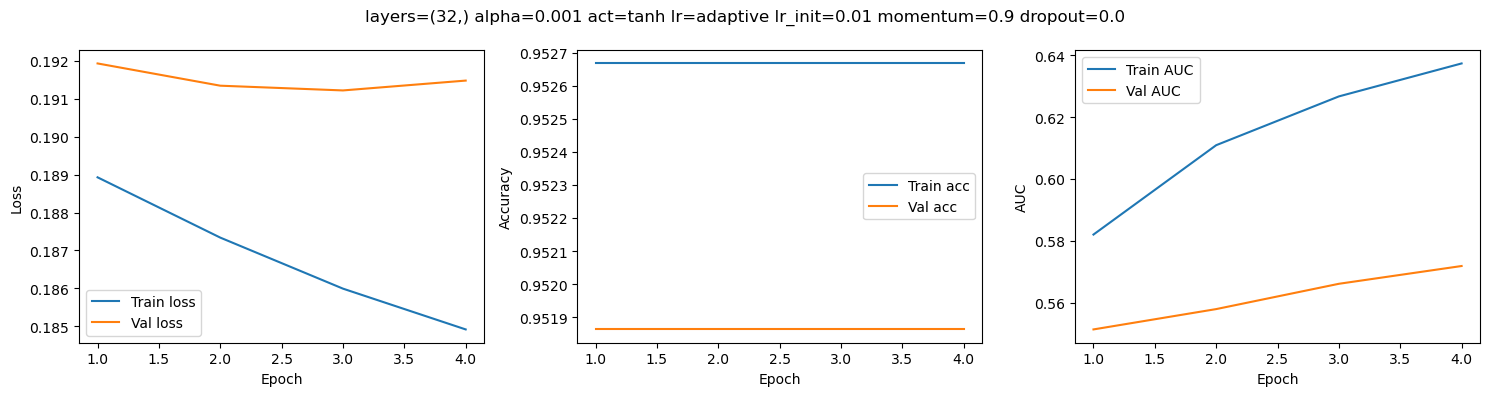

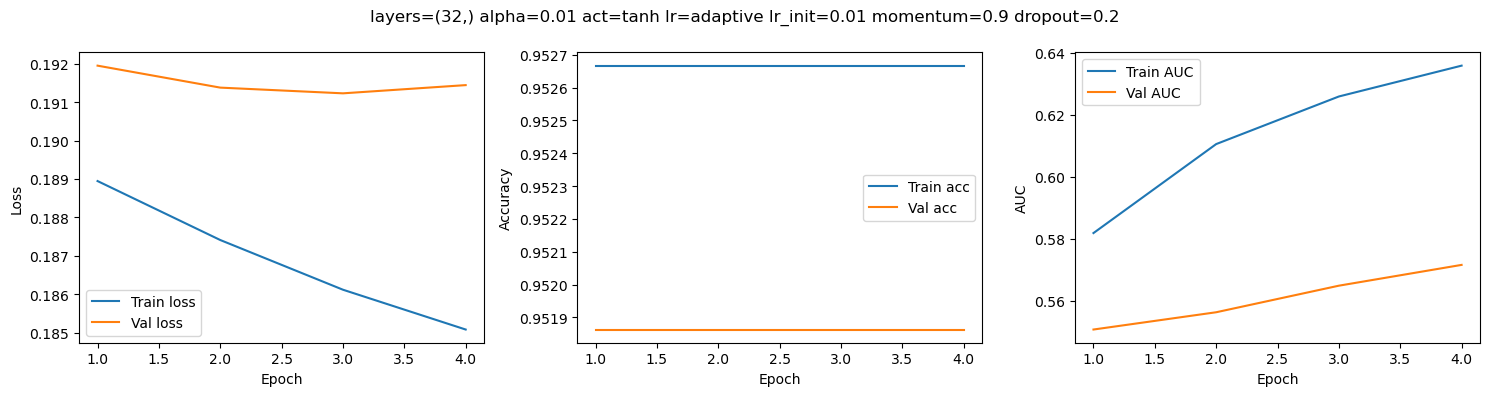

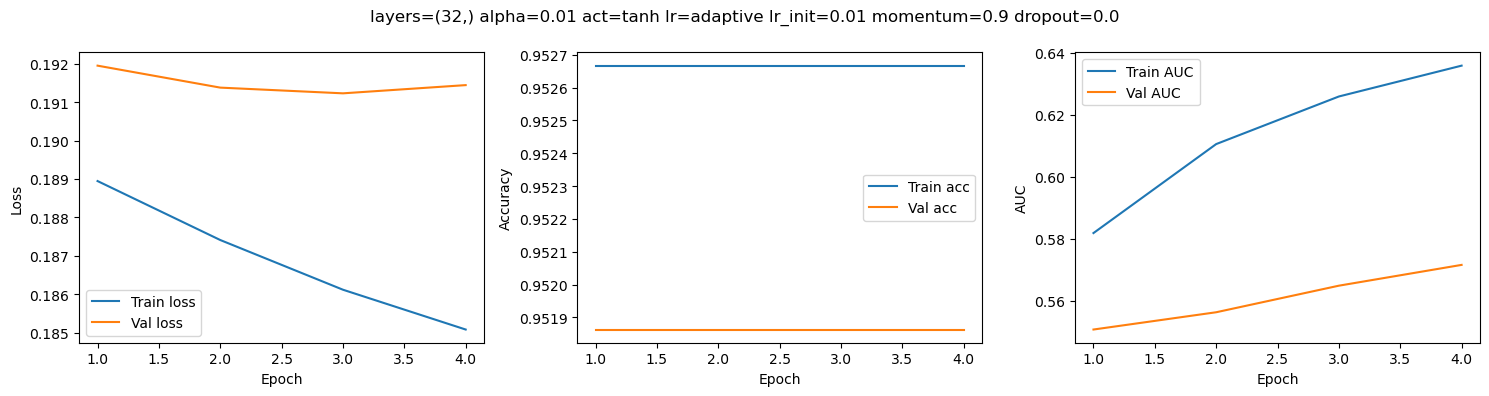

In [13]:
# Get top entries with the smallest val_error and biggest increase in val_auc
top_results = []
num_iterations = 0
for idx, row in filtered_results.iterrows():
    if num_iterations >= 10:
        break
    key = (
        f"layers={row['hidden_layers']} alpha={row['alpha']} act={row['activation']} "
        f"lr={row['learning_rate']} lr_init={row['learning_rate_init']} momentum={row['momentum']} "
        f"dropout={row['dropout_rate']}"
    )
    history_df = train_histories[key]
    # Calculate increase in val_auc
    val_auc_increase = history_df['val_auc'].iloc[-1] - history_df['val_auc'].iloc[0]
    if val_auc_increase > 0.01:  # Threshold for significant increase
        top_results.append((row, val_auc_increase))
        plot_training_history(history_df, title=key)
        num_iterations += 1

Best Result with most dramatic increase in val_auc:
hidden_layers            (32,)
alpha                     0.01
activation                tanh
learning_rate         adaptive
learning_rate_init        0.01
momentum                   0.9
dropout_rate               0.2
best_val_loss         0.191229
dev_accuracy          0.951863
dev_auc               0.571522
epochs_run                   4
Name: 11, dtype: object
Increase in val_auc: 0.0209


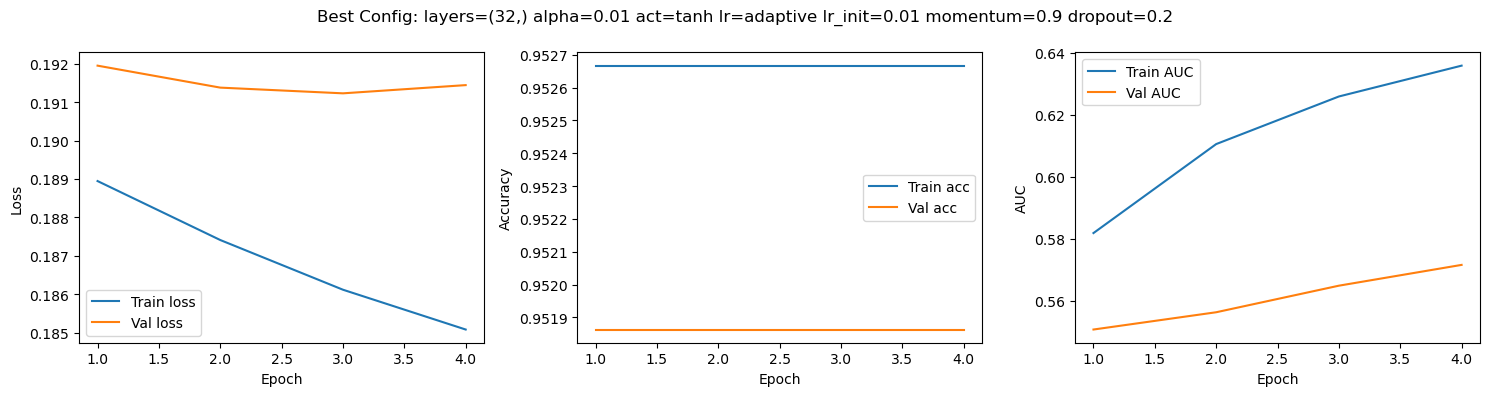

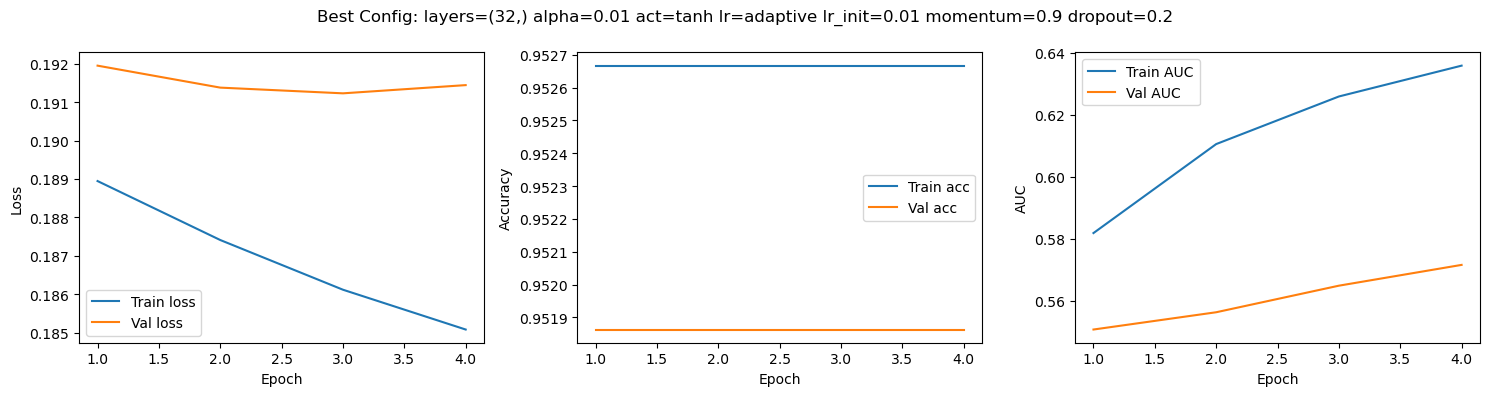

In [14]:
# Get entry with most dramatic increase in val_auc
top_results.sort(key=lambda x: x[1], reverse=True)
best_result, best_increase = top_results[0]
print("Best Result with most dramatic increase in val_auc:")
print(best_result)
print(f"Increase in val_auc: {best_increase:.4f}")

# Plot them
key = (
    f"layers={best_result['hidden_layers']} alpha={best_result['alpha']} act={best_result['activation']} "
    f"lr={best_result['learning_rate']} lr_init={best_result['learning_rate_init']} momentum={best_result['momentum']} "
    f"dropout={best_result['dropout_rate']}"
)
history_df = train_histories[key]
plot_training_history(history_df, title=f"Best Config: {key}")